In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("menzo_sales_data.csv")

In [3]:
df.head()

,Order_ID,Date,Product_Name,Category,Price,Cost_Price,Quantity,Customer_ID,Payment_Mode,Discount,Revenue,Profit
0,1,2025-04-18,Cap,Accessories,302,192.44,1,1171,Card,5,302,109.56
1,2,2025-11-10,Cap,Accessories,730,501.75,3,1106,Cash,15,2190,684.75
2,3,2026-01-27,Shirt,Topwear,826,572.04,4,1061,Cash,0,3304,1015.84
3,4,2026-02-20,Lower,Bottomwear,599,336.67,2,1015,Cash,5,1198,524.66
4,5,2025-04-20,Lower,Bottomwear,466,305.18,3,1009,Card,20,1398,482.46


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      2000 non-null   int64  
 1   Date          2000 non-null   object 
 2   Product_Name  2000 non-null   object 
 3   Category      2000 non-null   object 
 4   Price         2000 non-null   int64  
 5   Cost_Price    2000 non-null   float64
 6   Quantity      2000 non-null   int64  
 7   Customer_ID   2000 non-null   int64  
 8   Payment_Mode  2000 non-null   object 
 9   Discount      2000 non-null   int64  
 10  Revenue       2000 non-null   int64  
 11  Profit        2000 non-null   float64
dtypes: float64(2), int64(6), object(4)
memory usage: 187.6+ KB


In [5]:
df.describe()

,Order_ID,Price,Cost_Price,Quantity,Customer_ID,Discount,Revenue,Profit
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,859.679000,537.186740,2.480000,1101.802500,9.98750,2133.341000,799.123700
std,577.494589,483.994688,307.414041,1.132361,58.417504,7.11074,1610.031259,636.584263
min,1.000000,200.000000,101.890000,1.000000,1000.000000,0.00000,200.000000,53.630000
25%,500.750000,509.750000,314.095000,1.000000,1050.000000,5.00000,925.500000,338.715000
50%,1000.500000,768.500000,472.965000,2.000000,1104.000000,10.00000,1675.000000,616.060000
75%,1500.250000,1020.000000,668.340000,4.000000,1153.000000,15.00000,2894.250000,1062.720000
max,2000.000000,2490.000000,1777.320000,4.000000,1200.000000,20.00000,9288.000000,4360.880000


In [6]:
df['Date'] = pd.to_datetime(df['Date'])    # Convert Date to datetime

In [7]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Product_Name,0
Category,0
Price,0
Cost_Price,0
Quantity,0
Customer_ID,0
Payment_Mode,0
Discount,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import sqlite3
conn = sqlite3.connect('menzo.db')

Now, we are performing EDA on our dataset

In [10]:
df.to_sql('sales', conn, if_exists='replace', index=False)

2000

In [11]:
pd.read_sql("SELECT * FROM sales LIMIT 5", conn)

,Order_ID,Date,Product_Name,Category,Price,Cost_Price,Quantity,Customer_ID,Payment_Mode,Discount,Revenue,Profit
0,1,2025-04-18 00:00:00,Cap,Accessories,302,192.44,1,1171,Card,5,302,109.56
1,2,2025-11-10 00:00:00,Cap,Accessories,730,501.75,3,1106,Cash,15,2190,684.75
2,3,2026-01-27 00:00:00,Shirt,Topwear,826,572.04,4,1061,Cash,0,3304,1015.84
3,4,2026-02-20 00:00:00,Lower,Bottomwear,599,336.67,2,1015,Cash,5,1198,524.66
4,5,2025-04-20 00:00:00,Lower,Bottomwear,466,305.18,3,1009,Card,20,1398,482.46


🎯 1. Sales Performance Analysis


🥇 Total Revenue & Profit

In [12]:
pd.read_sql("""SELECT
    SUM(Revenue) AS Total_Revenue,
    SUM(Profit) AS Total_Profit
FROM sales""", conn)

,Total_Revenue,Total_Profit
0,4266682,1598247.4


Revenue By Category

In [13]:
pd.read_sql("""SELECT
    Category,
    SUM(Revenue) AS Revenue
FROM sales
GROUP BY Category
ORDER BY Revenue DESC""", conn)

,Category,Revenue
0,Topwear,1235996
1,Ethnic,1128626
2,Accessories,1075531
3,Bottomwear,476517
4,Innerwear,350012


Top Selling Products (By quantity)

In [14]:
pd.read_sql(""" SELECT
    Product_Name,
    SUM(Quantity) AS Total_Sold
FROM sales
GROUP BY Product_Name
ORDER BY Total_Sold DESC""", conn)

,Product_Name,Total_Sold
0,Kurta,679
1,Shirt,658
2,Lower,646
3,Cap,619
4,T-shirt,607
5,Belt,594
6,Wallet,584
7,Undergarments,573


🧍 2. Customer Behavior Analysis

Average Order Value

In [15]:
pd.read_sql("""SELECT
    SUM(Revenue) / COUNT(DISTINCT Order_ID) AS Avg_Order_Value
FROM sales""", conn)

,Avg_Order_Value
0,2133


Repeat Customers

In [16]:
pd.read_sql("""SELECT
    Customer_ID,
    COUNT(Order_ID) AS Orders_Count
FROM sales
GROUP BY Customer_ID
HAVING Orders_Count > 1
ORDER BY Orders_Count DESC""",conn)

,Customer_ID,Orders_Count
0,1172,18
1,1154,18
2,1127,18
3,1025,18
4,1191,17
...,...,...
196,1057,4
197,1059,3
198,1031,3
199,1010,3


Most Common Purchase Quantity

In [17]:
pd.read_sql("""SELECT
    Quantity,
    COUNT(*) AS Frequency
FROM sales
GROUP BY Quantity
ORDER BY Frequency DESC;""",conn)

,Quantity,Frequency
0,1,525
1,4,507
2,2,497
3,3,471


📦 3. Inventory Optimization

Least Selling Products

In [18]:
pd.read_sql("""SELECT
    Product_Name,
    SUM(Quantity) AS Total_Sold
FROM sales
GROUP BY Product_Name
ORDER BY Total_Sold ASC;""",conn)

,Product_Name,Total_Sold
0,Undergarments,573
1,Wallet,584
2,Belt,594
3,T-shirt,607
4,Cap,619
5,Lower,646
6,Shirt,658
7,Kurta,679


High Demand Products

In [19]:
pd.read_sql("""SELECT
    Product_Name,
    SUM(Quantity) AS Total_Sold
FROM sales
GROUP BY Product_Name
ORDER BY Total_Sold DESC
LIMIT 5;""",conn)

,Product_Name,Total_Sold
0,Kurta,679
1,Shirt,658
2,Lower,646
3,Cap,619
4,T-shirt,607


📅 4. Seasonal / Monthly Trends

Monthly Revenue Trend

In [20]:
pd.read_sql("""SELECT
    strftime('%m', Date) AS Month,
    SUM(Revenue) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Month;""",conn)

,Month,Revenue
0,01,232862
1,02,501970
2,03,889757
3,04,501130
4,05,241987
5,06,272135
6,07,306017
7,08,255380
8,09,245243
9,10,285152


Best Performing Month

In [21]:
pd.read_sql("""SELECT
    strftime('%m', Date) AS Month,
    SUM(Revenue) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Revenue DESC
LIMIT 1;""",conn)

,Month,Revenue
0,03,889757


💰 5. Profitability Analysis

Profit by Category

In [22]:
pd.read_sql("""SELECT
    Category,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Profit DESC;""",conn)

,Category,Total_Profit
0,Topwear,461796.03
1,Ethnic,425925.20
2,Accessories,403912.90
3,Bottomwear,175219.70
4,Innerwear,131393.57


Low Profit Products

In [23]:
pd.read_sql("""SELECT
    Product_Name,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Product_Name
ORDER BY Total_Profit ASC;""",conn)

,Product_Name,Total_Profit
0,Wallet,131167.99
1,Undergarments,131393.57
2,Cap,133689.35
3,Belt,139055.56
4,T-shirt,167868.74
5,Lower,175219.70
6,Shirt,293927.29
7,Kurta,425925.20


🏷️ 6. Pricing Strategy

Price Range Analysis - Low, Medium, High

In [24]:
pd.read_sql("""SELECT
    CASE
        WHEN Price < 500 THEN 'Low'
        WHEN Price BETWEEN 500 AND 1000 THEN 'Medium'
        ELSE 'High'
    END AS Price_Range,
    COUNT(*) AS Total_Orders,
    SUM(Quantity) AS Total_Quantity_Sold,
    SUM(Revenue) AS Total_Revenue,
    AVG(Revenue) AS Avg_Revenue_Per_Order
FROM sales
GROUP BY Price_Range
ORDER BY Total_Revenue DESC;""",conn)

,Price_Range,Total_Orders,Total_Quantity_Sold,Total_Revenue,Avg_Revenue_Per_Order
0,High,518,1295,1951375,3767.133205
1,Medium,999,2488,1890328,1892.220220
2,Low,483,1177,424979,879.873706


🧾 7. Discount Analysis

Discount vs Revenue

In [25]:
pd.read_sql("""SELECT
    Discount,
    AVG(Revenue) AS Avg_Revenue
FROM sales
GROUP BY Discount
ORDER BY Discount;""",conn)

,Discount,Avg_Revenue
0,0,2047.034146
1,5,2055.192308
2,10,2284.431078
3,15,2089.697733
4,20,2190.037129


Best Discount Level

In [26]:
pd.read_sql("""SELECT
    Discount,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Discount
ORDER BY Total_Revenue DESC;""",conn)

,Discount,Total_Revenue
0,10,911488
1,20,884775
2,0,839284
3,15,829610
4,5,801525


💳 8. Payment Mode Analysis

Transactions by Payment Mode

In [27]:
pd.read_sql("""SELECT
    Payment_Mode,
    COUNT(*) AS Transactions
FROM sales
GROUP BY Payment_Mode
ORDER BY Transactions DESC;""",conn)

,Payment_Mode,Transactions
0,Cash,681
1,Card,677
2,UPI,642


Revenue by Payment Mode

In [28]:
pd.read_sql("""SELECT
    Payment_Mode,
    SUM(Revenue) AS Revenue
FROM sales
GROUP BY Payment_Mode;""",conn)

,Payment_Mode,Revenue
0,Card,1401831
1,Cash,1480110
2,UPI,1384741


📊 9. Category Contribution

How much each category contributes to the total revenue(%)

In [29]:
pd.read_sql("""SELECT
    Category,
    SUM(Revenue) * 100.0 / (SELECT SUM(Revenue) FROM sales) AS Contribution_Percentage
FROM sales
GROUP BY Category
ORDER BY Contribution_Percentage DESC;""",conn)

,Category,Contribution_Percentage
0,Topwear,28.968552
1,Ethnic,26.452077
2,Accessories,25.207667
3,Bottomwear,11.168327
4,Innerwear,8.203377


🥇 Top 5 Customers by Spending

In [30]:
pd.read_sql("""SELECT
    Customer_ID,
    SUM(Revenue) AS Total_Spent
FROM sales
GROUP BY Customer_ID
ORDER BY Total_Spent DESC
LIMIT 5;""",conn)

,Customer_ID,Total_Spent
0,1025,45888
1,1127,45411
2,1106,41428
3,1172,40645
4,1154,39594


📊 Daily Sales Trend

In [31]:
pd.read_sql("""SELECT
    Date,
    SUM(Revenue) AS Daily_Revenue
FROM sales
GROUP BY Date
ORDER BY Date;""",conn)

,Date,Daily_Revenue
0,2025-04-12 00:00:00,4768
1,2025-04-13 00:00:00,5354
2,2025-04-14 00:00:00,3185
3,2025-04-15 00:00:00,11315
4,2025-04-16 00:00:00,17482
...,...,...
359,2026-04-08 00:00:00,12689
360,2026-04-09 00:00:00,24487
361,2026-04-10 00:00:00,32668
362,2026-04-11 00:00:00,13426


## **Data Visualization (EDA)**

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

📊 1. Revenue by Category (Seaborn Barplot)

/tmp/ipykernel_4223/154595770.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x='Category', y='Revenue', palette = "Dark2")


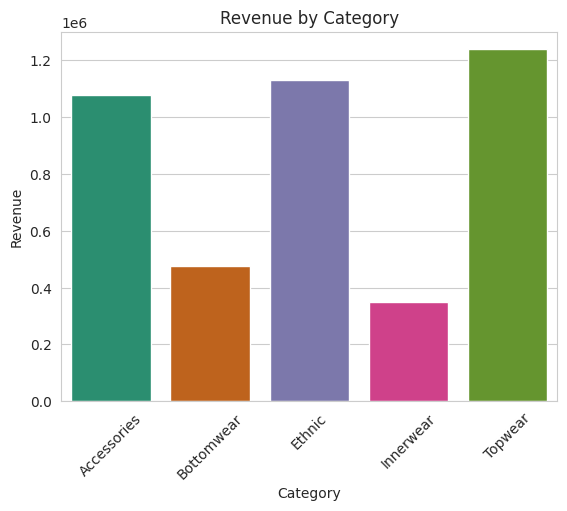

In [33]:
cat_rev = df.groupby('Category', as_index=False)['Revenue'].sum()

sns.barplot(data=cat_rev, x='Category', y='Revenue', palette = "Dark2")
plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.show()

👉 Insight: Topwear category drives maximum revenue

📈 2. Monthly Sales Trend (Matplotlib Line Plot)

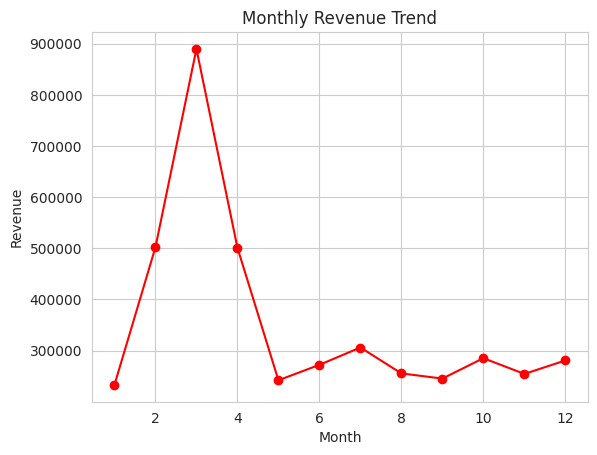

In [34]:
df['Month'] = df['Date'].dt.month
monthly = df.groupby('Month')['Revenue'].sum().reset_index()

plt.plot(monthly['Month'], monthly['Revenue'], marker='o', color = "red")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

👉 Insight: Revenue peaks in March, with a sharp rise from February and decline after April

🥇 3. Top Selling Products (Seaborn)

/tmp/ipykernel_4223/1862052898.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Product_Name', y='Quantity', palette = "Set2")


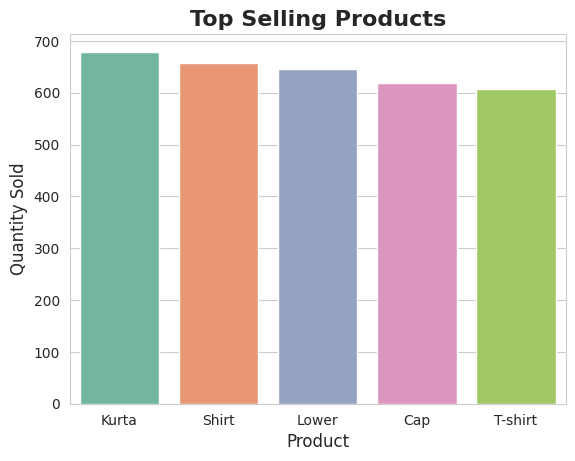

In [48]:
top_products = df.groupby('Product_Name', as_index=False)['Quantity'].sum() \
                .sort_values(by='Quantity', ascending=False)

sns.barplot(data=top_products, x='Product_Name', y='Quantity', palette = "Set2")
plt.title("Top Selling Products", fontsize = 16, fontweight = "bold")
plt.xlabel("Product", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

👉 Insight: The top 5 selling products are -Kurta, Shirt, Lowers, Caps and T-shirts. So the inventory needs to be optimized for them.

💰 4. Profit by Category (Seaborn)

/tmp/ipykernel_4223/3866446344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_cat, x='Category', y='Profit', palette = "Dark2")


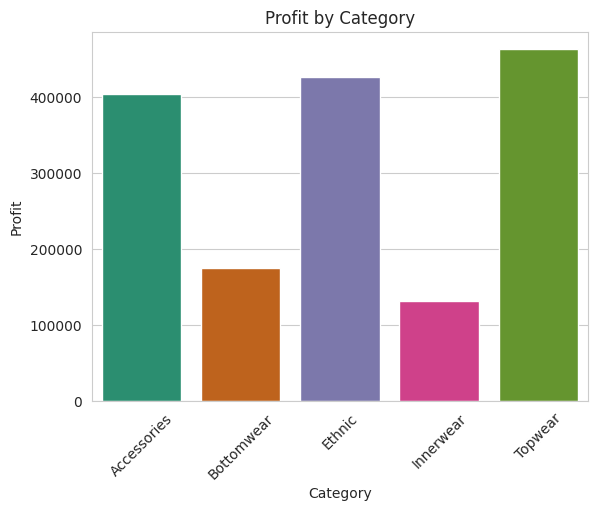

In [51]:
profit_cat = df.groupby('Category', as_index=False)['Profit'].sum()

sns.barplot(data=profit_cat, x='Category', y='Profit', palette = "Dark2")
plt.title("Profit by Category")
plt.xticks(rotation=45)
plt.show()

👉 Topwear generates the highest profit, while Innerwear and Bottomwear contribute significantly less, indicating a strong performance gap across categories.

🏷️ 5. Discount vs Revenue (Seaborn Boxplot 🔥)

/tmp/ipykernel_4223/3405727875.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Discount', y='Revenue',palette='coolwarm',showfliers=False)


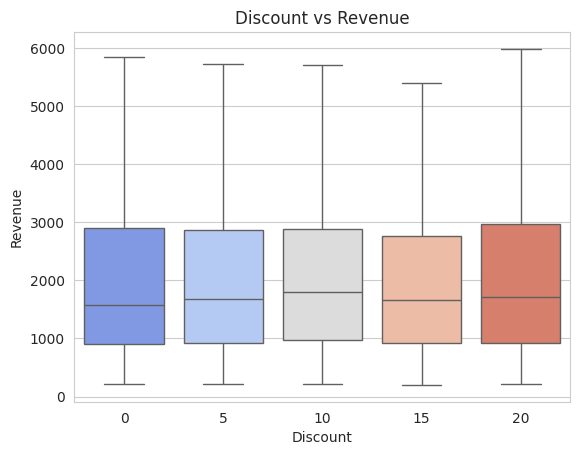

In [57]:
sns.boxplot(data=df, x='Discount', y='Revenue',palette='coolwarm',showfliers=False)
plt.title("Discount vs Revenue")
plt.show()

👉 Revenue distribution remains fairly consistent across all discount levels, indicating that increasing discounts does not significantly boost revenue.

🔥 9. Correlation Heatmap

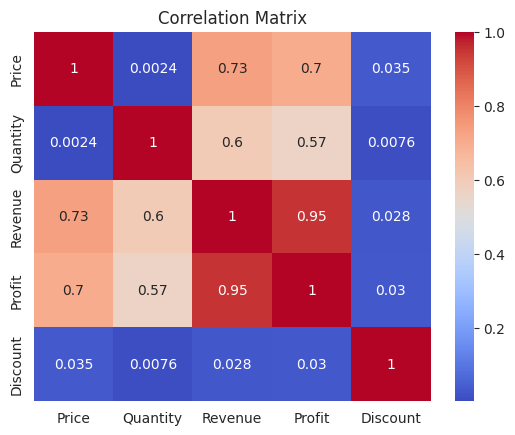

In [58]:
corr = df[['Price', 'Quantity', 'Revenue', 'Profit', 'Discount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

👉 Revenue and Profit are highly correlated (0.95), while Discount shows almost no impact on any variable, indicating pricing and quantity drive business performance more than discounts.